# TF-IDF Analysis by Kanal Berita (News Channel)

Identifies dominant keywords per news outlet by computing TF-IDF scores grouped by source media.

**Pipeline:**
1. Extract news channel/publisher name from article URLs
2. Group articles by channel
3. Compute TF-IDF per channel to reveal differences in coverage focus

In [22]:
!pip install nltk Sastrawi pandas scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


## 1. Load Dataset

In [24]:
path = "../../preprocessed/dataset_preprocessed_bert.csv"
df = pd.read_csv(path)
df = df.dropna(subset=['konten_preprocessed'])

print(f"Dataset: {len(df)} articles")
print(f"Columns: {list(df.columns)}")
df.head(3)

Dataset: 999 articles
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...


## 2. Extract News Channel from URL

We parse the domain from each article URL and map it to a human-readable channel name.

In [25]:
def extract_channel(url):
    if not isinstance(url, str):
        return 'Unknown'
    
    try:
        parsed = urlparse(url)
        domain = parsed.netloc.lower()
        # Remove www. prefix
        domain = re.sub(r'^www\.', '', domain)
    except:
        return 'Unknown'
    
    # Map domains to channel names
    # ADJUST THIS: Add/modify mappings based on your dataset's actual sources
    channel_map = {
        # Major national portals
        'kompas.com': 'Kompas', 'ekonomi.kompas.com': 'Kompas',
        'money.kompas.com': 'Kompas', 'nasional.kompas.com': 'Kompas',
        'internasional.kompas.com': 'Kompas',
        'detik.com': 'Detik', 'finance.detik.com': 'Detik',
        'news.detik.com': 'Detik',
        'cnbcindonesia.com': 'CNBC Indonesia',
        'cnnindonesia.com': 'CNN Indonesia',
        'tempo.co': 'Tempo', 'bisnis.tempo.co': 'Tempo',
        'liputan6.com': 'Liputan6', 'bisnis.liputan6.com': 'Liputan6',
        'tribunnews.com': 'Tribunnews',
        
        # Business/finance
        'kontan.co.id': 'Kontan', 'investasi.kontan.co.id': 'Kontan',
        'nasional.kontan.co.id': 'Kontan',
        'bisnis.com': 'Bisnis Indonesia', 'market.bisnis.com': 'Bisnis Indonesia',
        'katadata.co.id': 'Katadata',
        'investor.id': 'Investor Daily',
        'idnfinancials.com': 'IDN Financials',
        
        # Wire services
        'antaranews.com': 'Antara',
        'en.antaranews.com': 'Antara',
        
        # Other national
        'okezone.com': 'Okezone', 'economy.okezone.com': 'Okezone',
        'sindonews.com': 'SINDOnews', 'ekbis.sindonews.com': 'SINDOnews',
        'republika.co.id': 'Republika',
        'merdeka.com': 'Merdeka',
        'tirto.id': 'Tirto',
        'kumparan.com': 'Kumparan',
        'viva.co.id': 'VIVA',
        'jpnn.com': 'JPNN',
        'suara.com': 'Suara',
        'inews.id': 'iNews',
        'medcom.id': 'Medcom',
        'rmol.id': 'RMOL',
        
        # International (Indonesian editions)
        'bloomberg.com': 'Bloomberg',
        'reuters.com': 'Reuters',
        'bbc.com': 'BBC', 'bbc.co.uk': 'BBC',
        'voaindonesia.com': 'VOA Indonesia',
    }
    
    # Direct match
    if domain in channel_map:
        return channel_map[domain]
    
    # Subdomain match: try the base domain
    parts = domain.split('.')
    if len(parts) >= 2:
        base = '.'.join(parts[-2:])
        if base in channel_map:
            return channel_map[base]
    
    # Fuzzy match on known patterns
    for key, name in channel_map.items():
        if key in domain:
            return name
    
    # Return cleaned domain as fallback
    return domain.replace('.co.id', '').replace('.com', '').replace('.id', '').capitalize()


df['channel'] = df['url'].apply(extract_channel)

print("Channel distribution:")
channel_counts = df['channel'].value_counts()
print(channel_counts)
print(f"\nTotal unique channels: {df['channel'].nunique()}")

Channel distribution:
channel
CNBC Indonesia      195
Kompas              137
Bloombergtechnoz    104
Detik                80
Metrotvnews          60
                   ... 
Editorindonesia       1
Mediaindonesia        1
News.ddtc             1
Idxchannel            1
Agroindonesia         1
Name: count, Length: 86, dtype: int64

Total unique channels: 86


In [26]:
# ADJUST: Minimum articles per channel to include in analysis
MIN_ARTICLES = 5

valid_channels = channel_counts[channel_counts >= MIN_ARTICLES].index.tolist()
df_filtered = df[df['channel'].isin(valid_channels)].copy()

print(f"Channels with >= {MIN_ARTICLES} articles: {len(valid_channels)}")
print(f"Articles included: {len(df_filtered)} / {len(df)}")
print(f"\nChannels: {valid_channels}")

Channels with >= 5 articles: 24
Articles included: 913 / 999

Channels: ['CNBC Indonesia', 'Kompas', 'Bloombergtechnoz', 'Detik', 'Metrotvnews', 'Tempo', 'CNN Indonesia', 'Antara', 'Bisnis Indonesia', 'Dw', 'Kumparan', 'SINDOnews', 'BBC', 'VOA Indonesia', 'Liputan6', 'Akurat.co', 'Infobanknews', 'Kompas.tv', 'Republika', 'Cna', 'Indodax', 'Kabarbursa', 'Katadata', 'Suara']


## 3. Preprocessing

In [27]:
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

PUBLISHER_NOISE = sorted([
    'bloomberg news bloomberg', 'bloomberg news', 'bloomberg com',
    'reuters thomson reuters', 'thomson reuters', 'reuters com',
    'associated press', 'the associated press',
    'bloomberg technoz jakarta', 'cnbc indonesia', 'cnn indonesia',
    'kompas com', 'kompas tv', 'tribunnews com', 'detik com',
    'detikfinance', 'detikcom', 'liputan6 com', 'tempo co',
    'kontan co id', 'bisnis com', 'bisnis indonesia',
    'katadata co id', 'katadata', 'antara news', 'antaranews com',
    'okezone com', 'sindonews com', 'tirto id', 'kumparan com',
    'baca juga', 'baca selengkapnya', 'simak juga',
    'hak cipta', 'all rights reserved', 'copyright',
    'unduh aplikasi', 'download aplikasi',
    'sindonews berita terbaru', 'channel sindonews berita',
    'whatsapp channel sindonews', 'berita terbaru hari',
    'konten melakukan crawling', 'continue with content',
    'gambas video cnn', 'von der leyen', 'ursula von der',
    'federal reserve the', 'reserve the fed',
], key=len, reverse=True)


def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    for phrase in PUBLISHER_NOISE:
        text = text.replace(phrase, ' ')
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) >= 3]
    return ' '.join(tokens)


print("Preprocessing...")
df_filtered['cleaned_text'] = df_filtered['konten_preprocessed'].apply(preprocess_text)
df_filtered = df_filtered[df_filtered['cleaned_text'].str.strip() != '']
print(f"Done! {len(df_filtered)} articles.")

Preprocessing...
Done! 913 articles.


## 4. TF-IDF per Kanal Berita

In [28]:
def tfidf_analysis(corpus, top_n=20):
    corpus_clean = [doc for doc in corpus if doc.strip()]
    if len(corpus_clean) < 2:
        return pd.DataFrame(columns=['Term', 'TF-IDF Score'])
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus_clean)
    features = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1
    result = pd.DataFrame({'Term': features, 'TF-IDF Score': mean_scores})
    return result.sort_values('TF-IDF Score', ascending=False).head(top_n).reset_index(drop=True)

print("TF-IDF function ready.")

TF-IDF function ready.


In [29]:
TOP_N = 20

tfidf_per_channel = {}

for channel in sorted(valid_channels):
    subset = df_filtered[df_filtered['channel'] == channel]
    corpus = subset['cleaned_text'].tolist()
    
    df_result = tfidf_analysis(corpus, TOP_N)
    df_result['Channel'] = channel
    df_result['Article Count'] = len(subset)
    tfidf_per_channel[channel] = df_result
    
    print(f"--- {channel} ({len(subset)} articles) ---")
    print(df_result[['Term', 'TF-IDF Score']].head(10).to_string(index=False))
    print()

--- Akurat.co (10 articles) ---
       Term  TF-IDF Score
      tarif      0.056528
      trump      0.053706
     negara      0.038339
     dagang      0.037853
  kebijakan      0.034845
      pasar      0.032813
perdagangan      0.032489
     barang      0.032180
      china      0.032059
    ekonomi      0.030761

--- Antara (38 articles) ---
       Term  TF-IDF Score
      tarif      0.039855
      trump      0.033404
     negara      0.029916
  indonesia      0.028783
  kebijakan      0.026699
      china      0.026500
perdagangan      0.025350
     persen      0.024451
   presiden      0.023929
     dagang      0.022368

--- BBC (15 articles) ---
         Term  TF-IDF Score
        tarif      0.037145
       negara      0.034351
        china      0.034010
        trump      0.032227
       sumber      0.027099
        pasar      0.026762
sumber gambar      0.026710
       gambar      0.026710
      ekonomi      0.026704
       barang      0.026535

--- Bisnis Indonesia (27 artic

## 5. Visualization

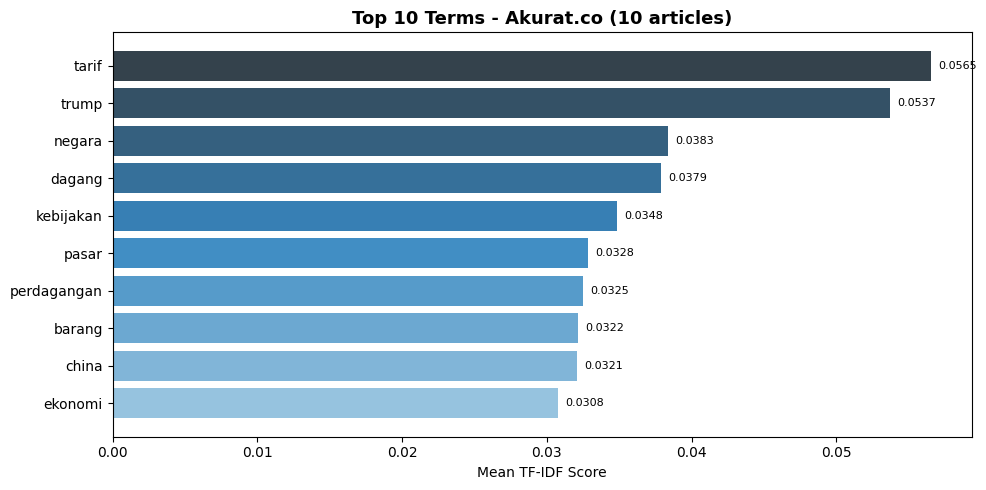

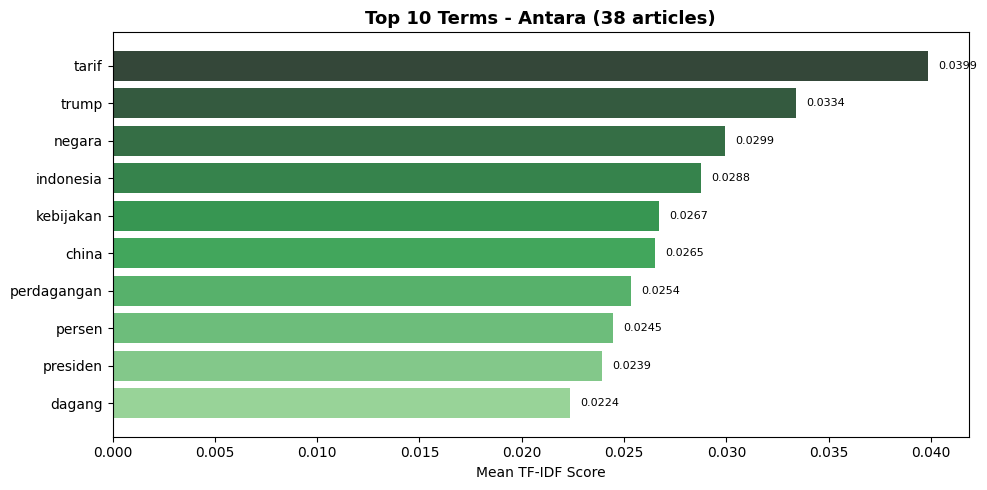

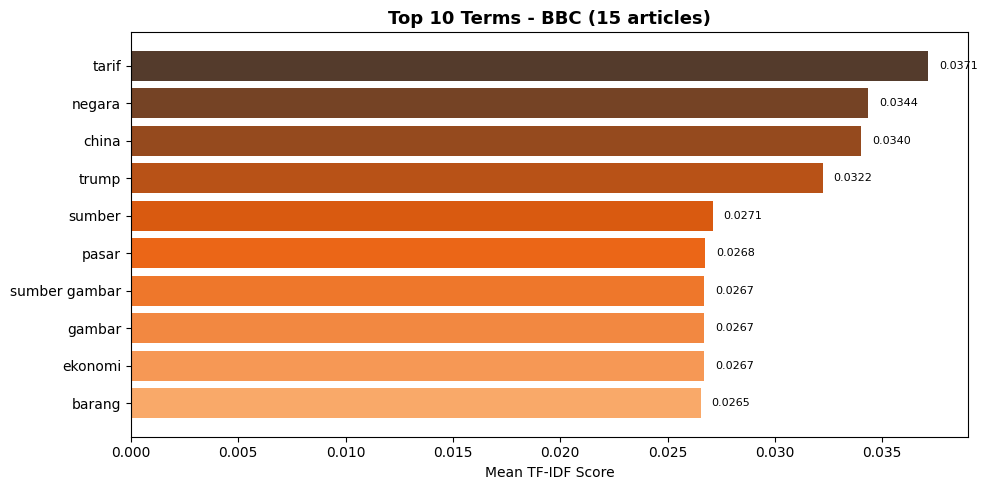

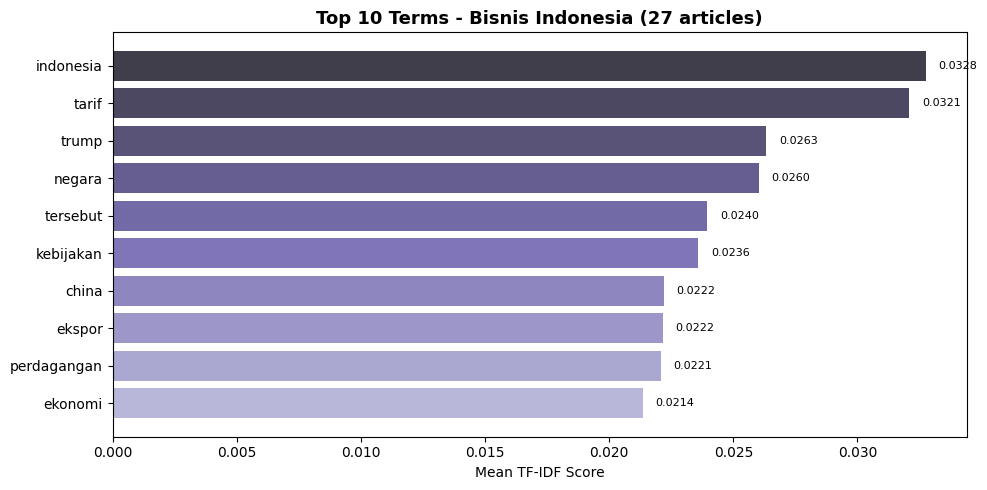

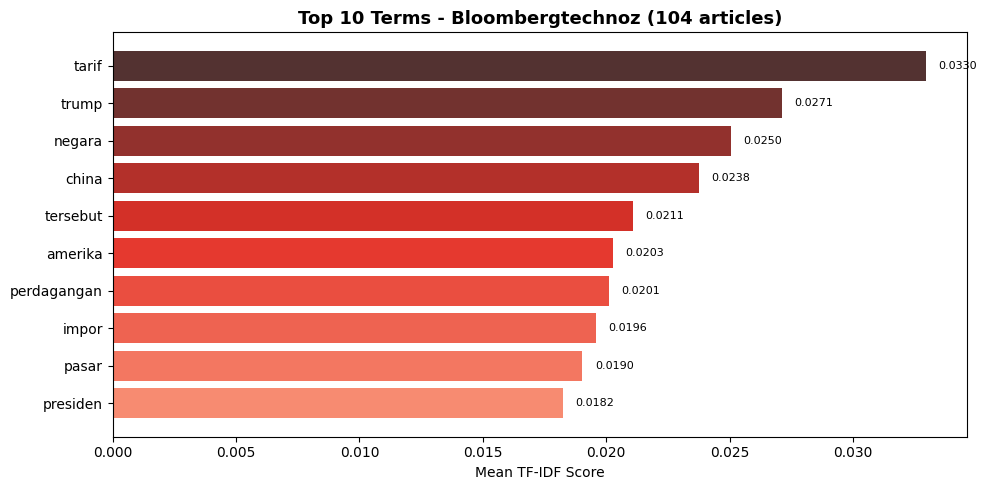

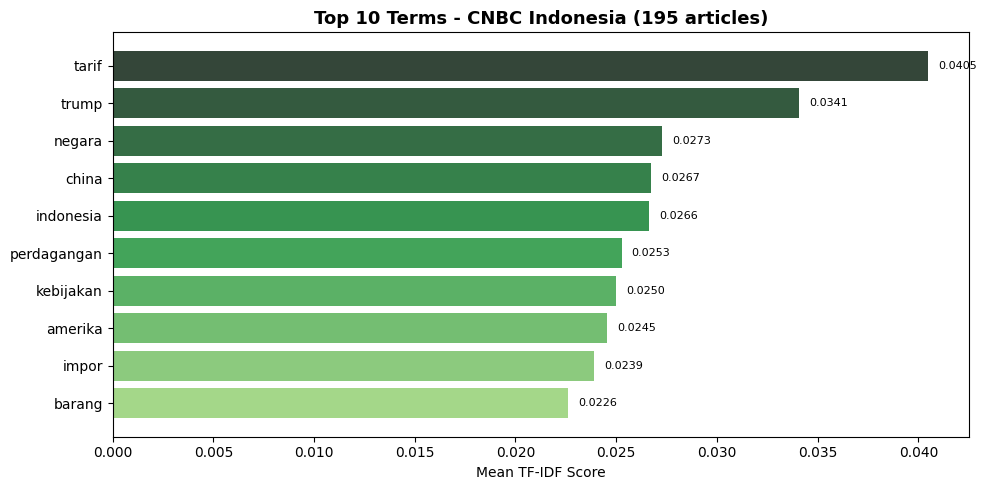

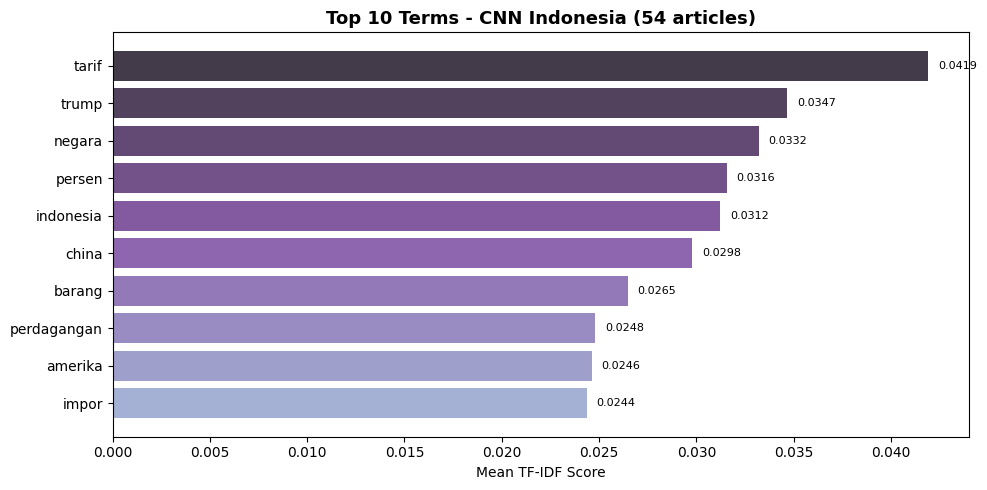

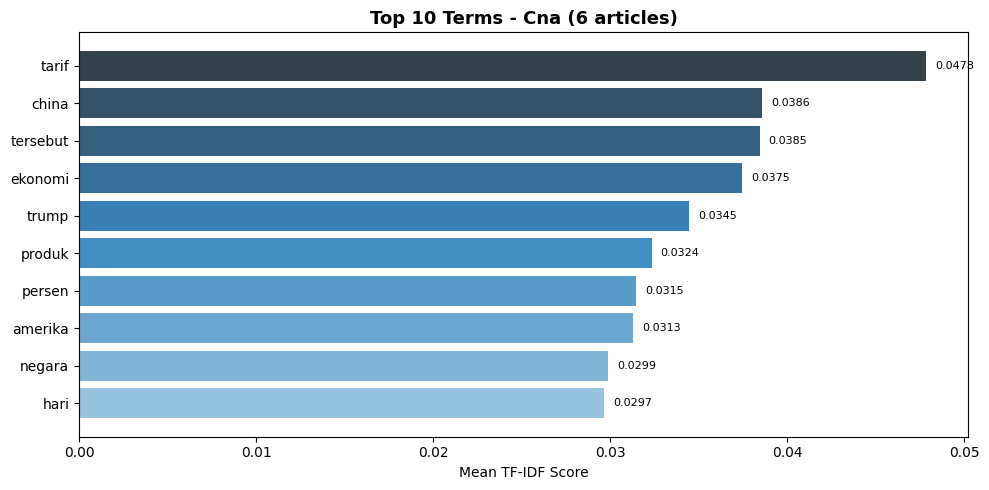

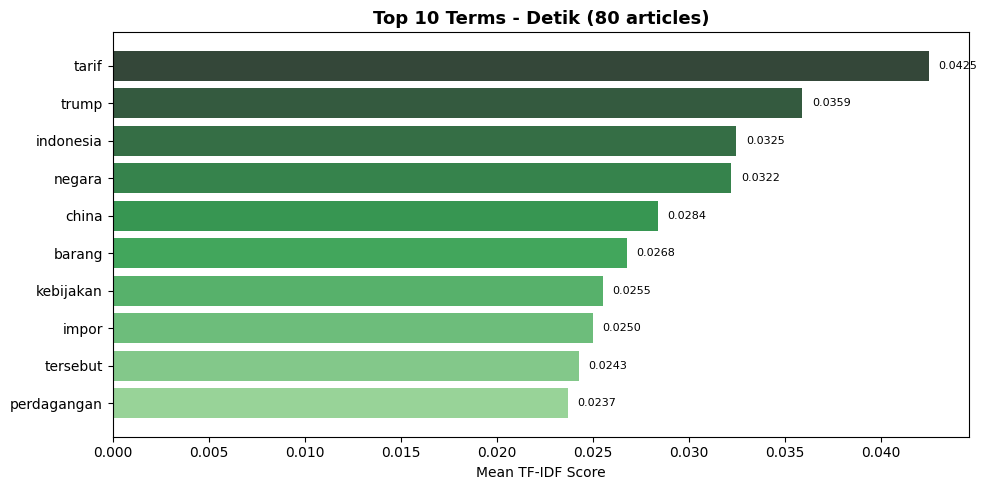

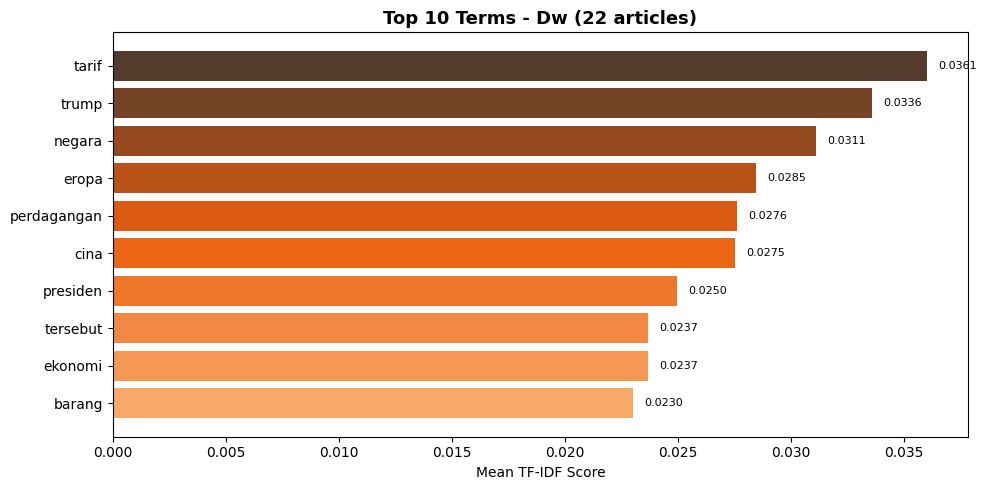

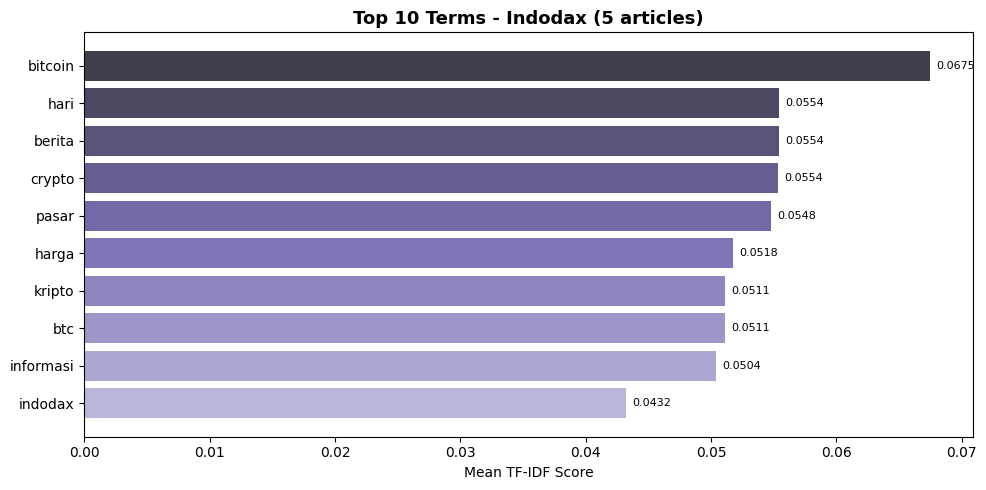

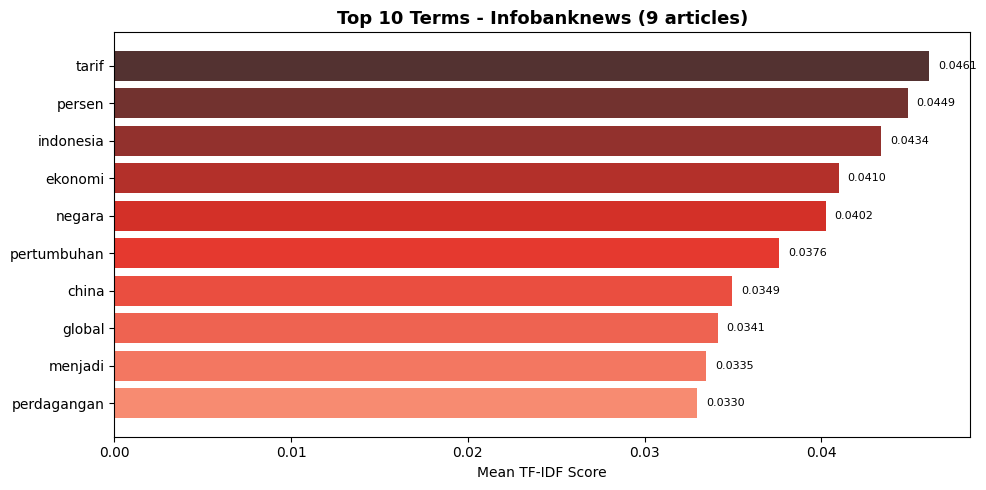

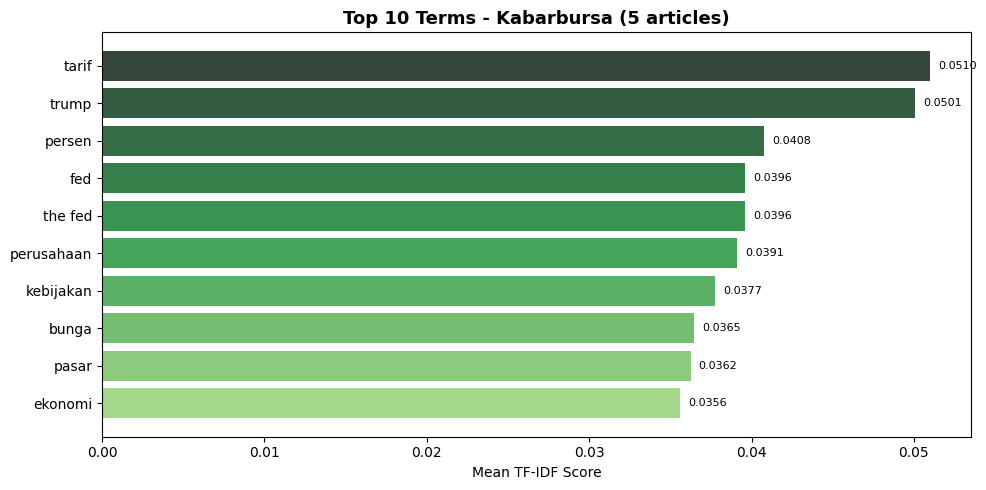

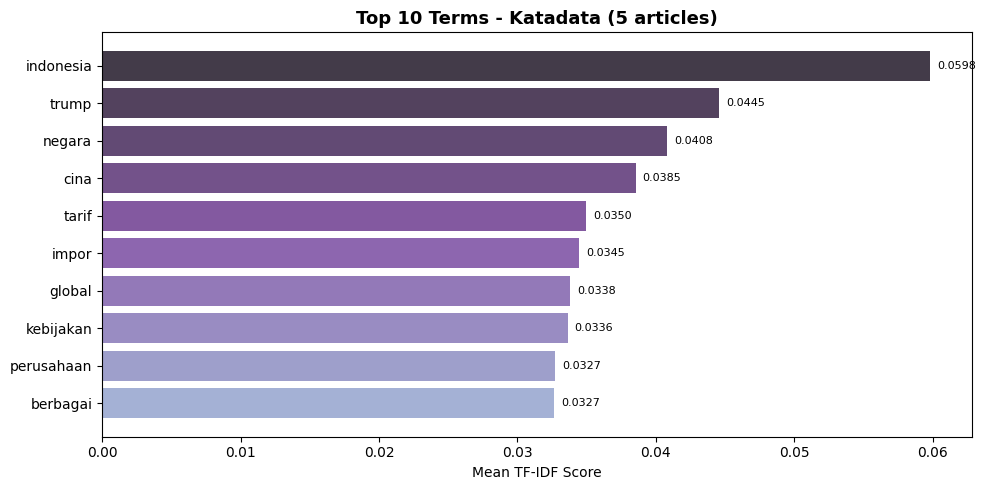

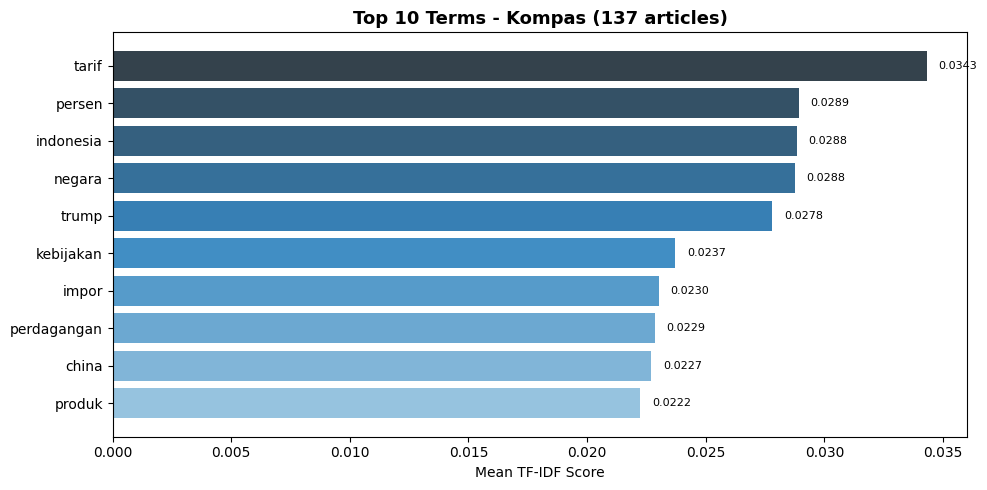

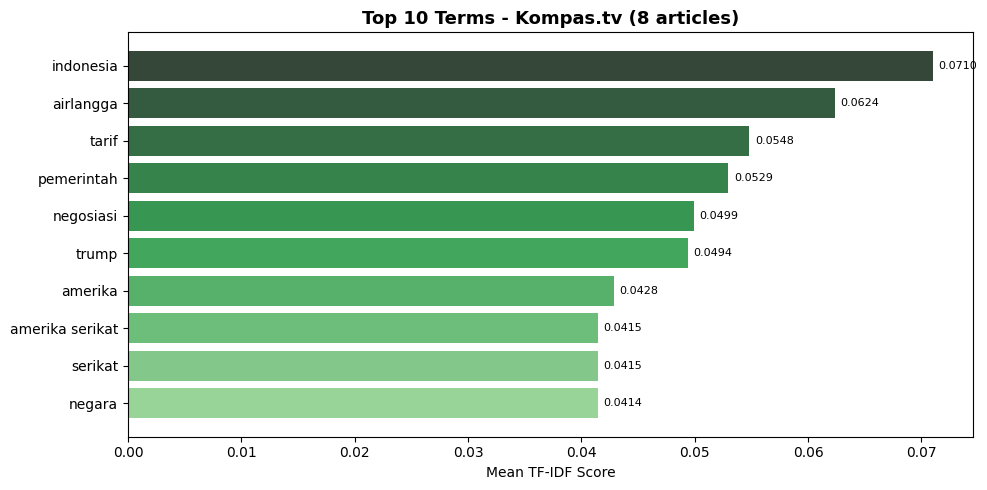

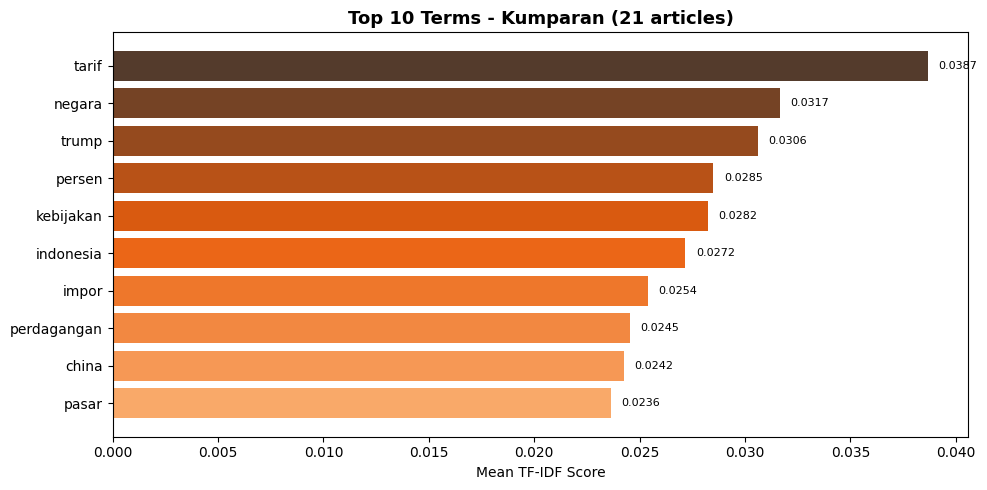

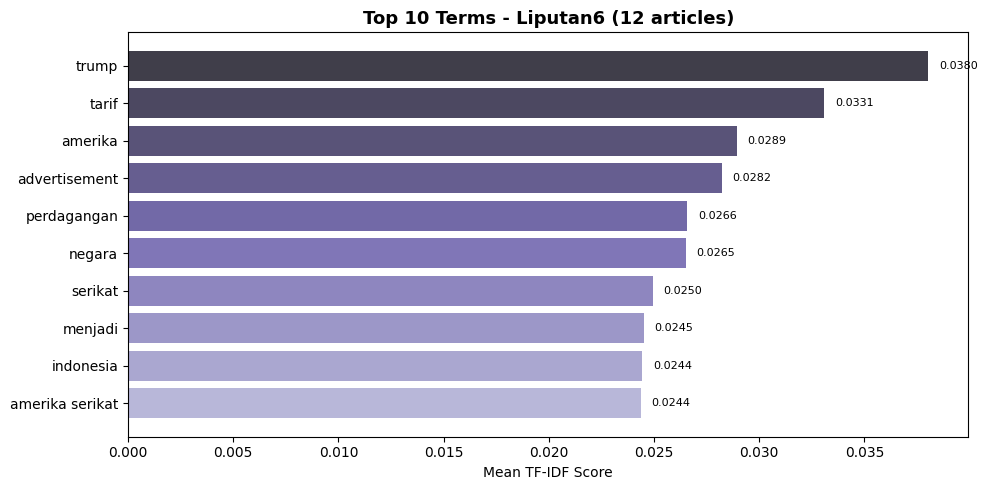

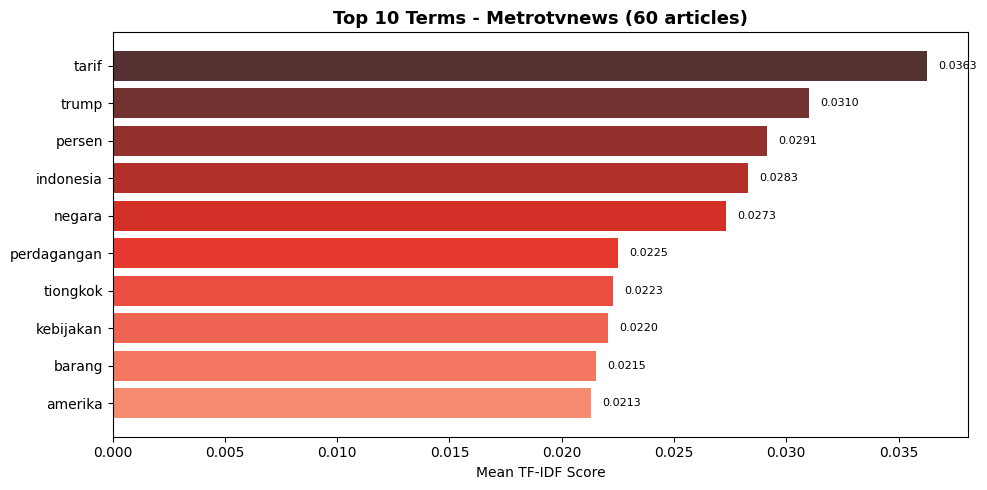

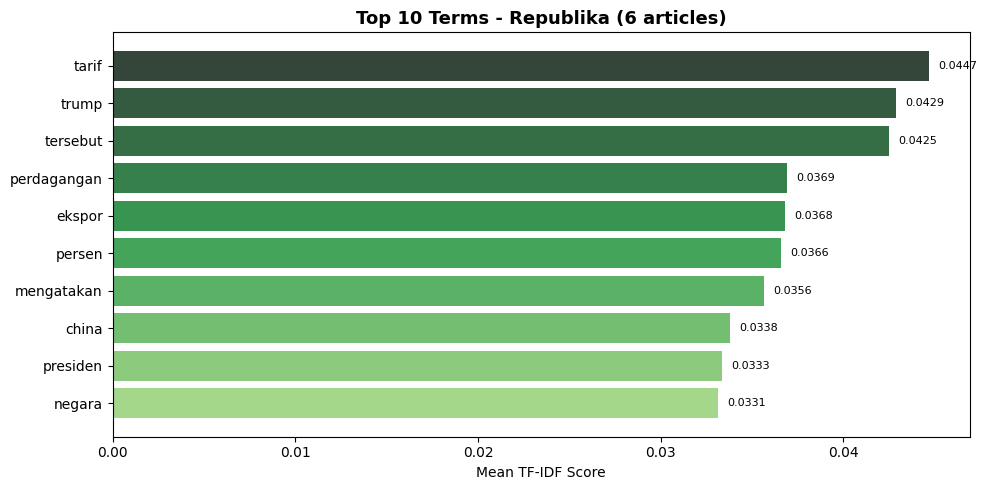

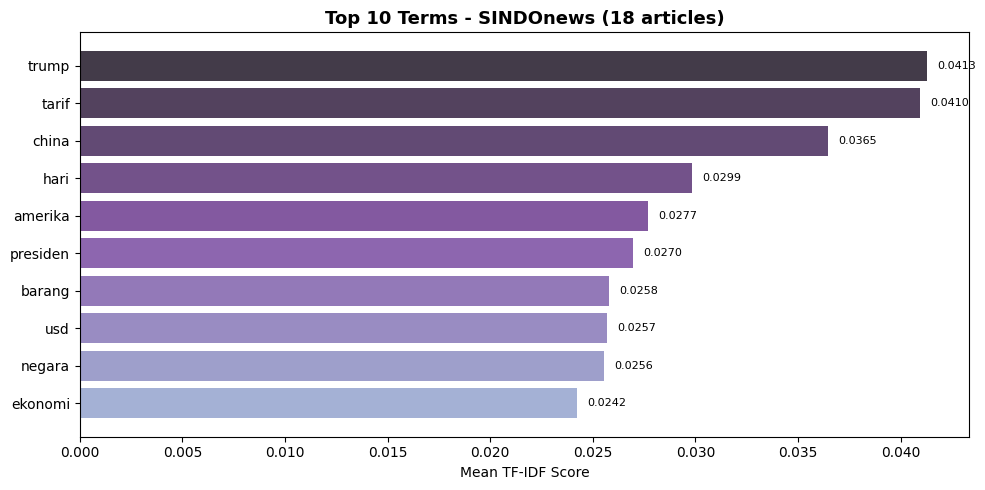

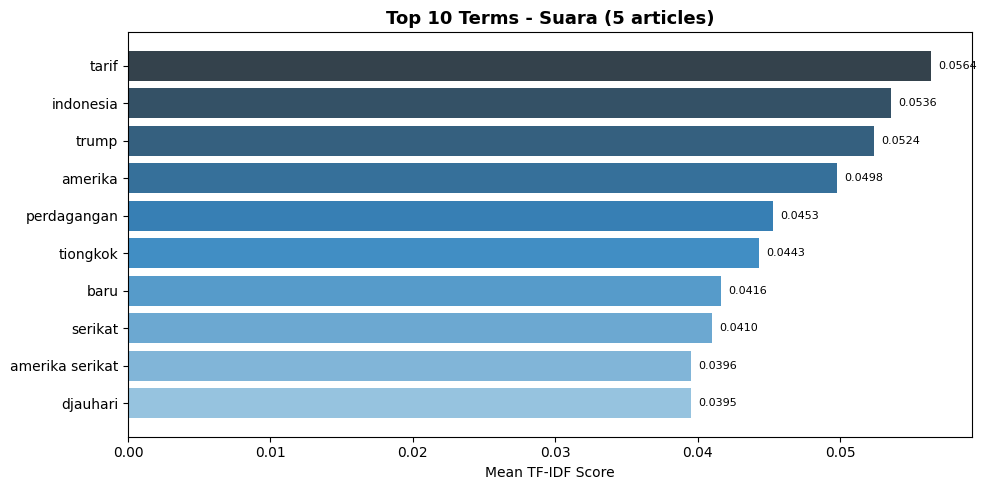

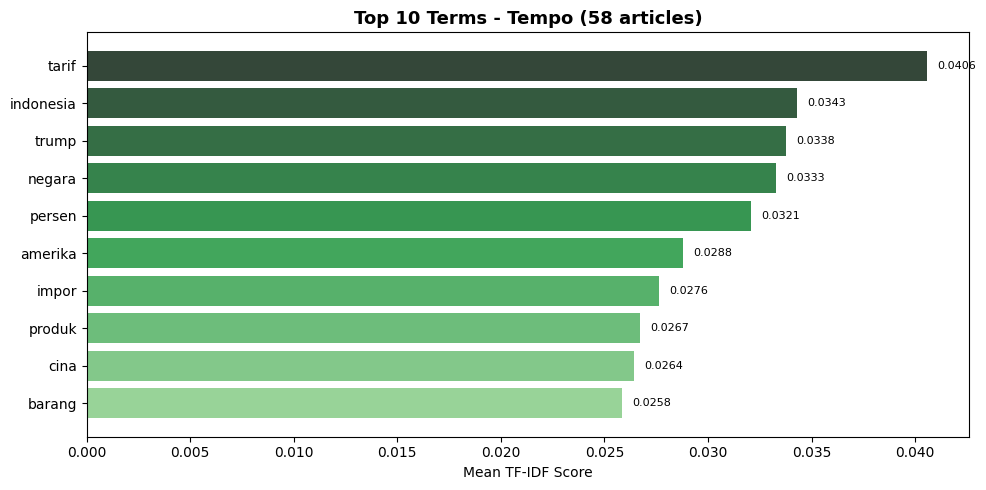

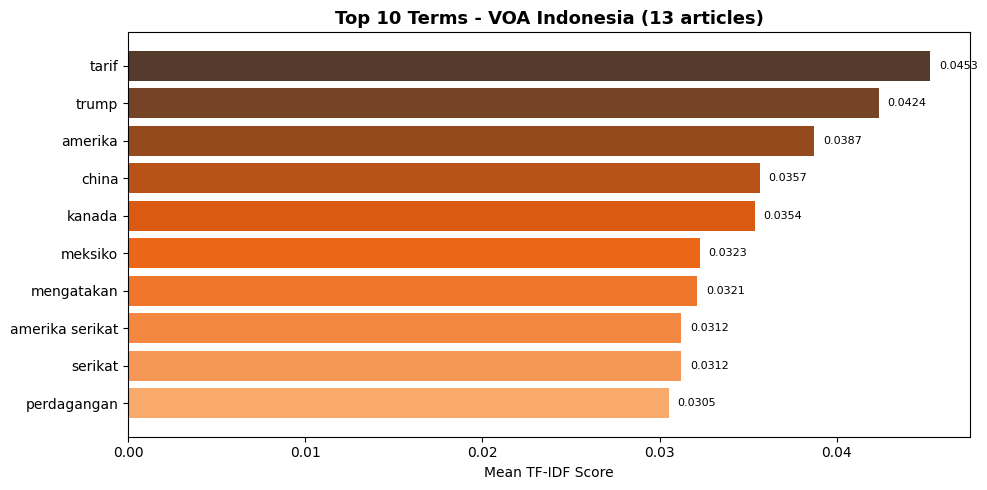

In [32]:
# Individual charts per channel
palettes = ['Blues_d', 'Greens_d', 'Oranges_d', 'Purples_d', 'Reds_d',
            'YlGn_d', 'BuPu_d',]

# 'RdPu_d', 'YlOrBr_d', 'GnBu_d'

for i, (channel, df_ch) in enumerate(sorted(tfidf_per_channel.items())):
    data = df_ch.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    pal = palettes[i % len(palettes)]
    colors = sns.color_palette(pal, len(data))
    ax.barh(data['Term'], data['TF-IDF Score'], color=colors)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'Top 10 Terms - {channel} ({data["Article Count"].iloc[0]} articles)',
                 fontsize=13, fontweight='bold')
    for j, val in enumerate(data['TF-IDF Score']):
        ax.text(val + 0.0005, j, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Export to CSV

In [31]:
import os

OUTPUT_DIR = "../../outputs/news-channel"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Combined
all_channels = pd.concat(tfidf_per_channel.values(), ignore_index=True)
all_channels.to_csv(f"{OUTPUT_DIR}/tfidf_by_channel.csv", index=False)
print(f"Exported: tfidf_by_channel.csv ({len(all_channels)} rows)")

# Channel mapping
df_filtered[['url', 'judul', 'channel']].to_csv(
    f"{OUTPUT_DIR}/article_channel_mapping.csv", index=False)
print(f"Exported: article_channel_mapping.csv ({len(df_filtered)} rows)")

# Channel stats
ch_stats = df_filtered.groupby('channel').agg(
    article_count=('judul', 'count'),
    avg_length=('konten_length', 'mean')
).reset_index().sort_values('article_count', ascending=False)
ch_stats.to_csv(f"{OUTPUT_DIR}/channel_statistics.csv", index=False)
print(f"Exported: channel_statistics.csv")

print(f"\nAll files: {os.path.abspath(OUTPUT_DIR)}")

Exported: tfidf_by_channel.csv (480 rows)
Exported: article_channel_mapping.csv (913 rows)
Exported: channel_statistics.csv

All files: d:\Code\kelompok-7-pba\outputs\news-channel
